In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def draw_fig1_math_large():
    # --- 設定 ---
    r = 3
    t = 4

    # ノード定義
    existing_nodes = [1, 2, 3, 4]
    new_node = 5

    # --- 計算ロジック ---
    k_outs = {1: 3, 2: 2, 3: 1, 4: 0}
    denom_str = "12+6\\omega" # 分母共通

    formulas = {}
    l_vals = {}
    omega_val = 1.0

    for n in existing_nodes:
        k = k_outs[n]
        if k > 0:
            numerator = f"3+{k}\\omega"
            l_val = 3 + k * omega_val
        else:
            numerator = "3"
            l_val = 3

        formulas[n] = f"$\\frac{{{numerator}}}{{{denom_str}}}$"
        l_vals[n] = l_val

    # サイズ計算用
    total_l = sum(l_vals.values())
    probs_numeric = {n: l_vals[n] / total_l for n in existing_nodes}

    # --- 描画準備 ---
    G = nx.DiGraph()
    G.add_nodes_from(existing_nodes)
    edges = [(2,1), (3,1), (3,2), (4,1), (4,2), (4,3)]

    # 図のサイズを拡大
    plt.figure(figsize=(18, 10))

    # ノード配置 (間隔を広めに)
    pos = {1: (0, 0), 2: (3, 0), 3: (6, 0), 4: (9, 0), 5: (13, 0)}

    # --- ノード描画 ---
    base_size = 2500
    node_sizes = [base_size + (probs_numeric[n] * 10000) for n in existing_nodes]
    node_colors = [plt.cm.Blues(0.2 + probs_numeric[n]*0.8) for n in existing_nodes]

    nx.draw_networkx_nodes(G, pos, nodelist=existing_nodes,
                           node_size=node_sizes, node_color=node_colors,
                           edgecolors='black', linewidths=2.5)

    # 新規ノード
    nx.draw_networkx_nodes(G, pos, nodelist=[new_node], node_size=4500,
                           node_color='#ff7f7f', edgecolors='red', linewidths=3.5)

    # ラベル (特大)
    nx.draw_networkx_labels(G, pos, font_size=24, font_weight='bold')

    # エッジ
    nx.draw_networkx_edges(G, pos, edgelist=edges,
                           connectionstyle="arc3,rad=0.2",
                           edge_color='gray', alpha=0.3, arrowstyle='->', arrowsize=25, width=2.0)

    potential_edges = [(5, i) for i in existing_nodes]
    nx.draw_networkx_edges(G, pos, edgelist=potential_edges,
                           style='dashed', edge_color='red', alpha=0.5,
                           connectionstyle="arc3,rad=-0.1", arrowstyle='->', arrowsize=30, width=2.5)

    # --- テキスト情報 (さらに大きく) ---

    # アリ5の説明
    plt.text(pos[5][0], 0.5, "New Ant\n(t=5)", ha='center', va='center',
             fontsize=24, color='red', fontweight='bold')

    # テキストのベース位置
    y_base = -0.4

    # 左側のヘッダー
    plt.text(-2.0, y_base, "Out-Degree $k_{out}$:", ha='right', fontsize=20, color='gray')
    plt.text(-2.0, y_base - 0.25, "Popularity $l(i,4)$:", ha='right', fontsize=20, color='blue')
    plt.text(-2.0, y_base - 0.60, "Probability $P(\Delta k(i,4)=1)$:", ha='right', fontsize=24, fontweight='bold')

    for n in existing_nodes:
        x = pos[n][0]
        # k_out
        plt.text(x, y_base, f"{k_outs[n]}", ha='center', fontsize=24, color='gray', fontweight='bold')

        # l(i)
        if k_outs[n] > 0:
            l_text = f"$3 + {k_outs[n]}\omega$"
        else:
            l_text = "$3$"
        plt.text(x, y_base - 0.25, l_text, ha='center', fontsize=24, color='blue')

        # 確率数式 (特大)
        plt.text(x, y_base - 0.60, formulas[n], ha='center', va='center', fontsize=32)

    # 表示範囲調整
    plt.xlim(-3, 15)
    plt.ylim(-1.2, 1.2)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

draw_fig1_math_large()

<>:94: SyntaxWarning: invalid escape sequence '\o'
<>:94: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_640499/1078651832.py:94: SyntaxWarning: invalid escape sequence '\o'
  l_text = f"$3+{k_outs[n]}\omega$" if k_outs[n]>0 else "$3$"


--- Regenerating Figure 1 (Compact) ---


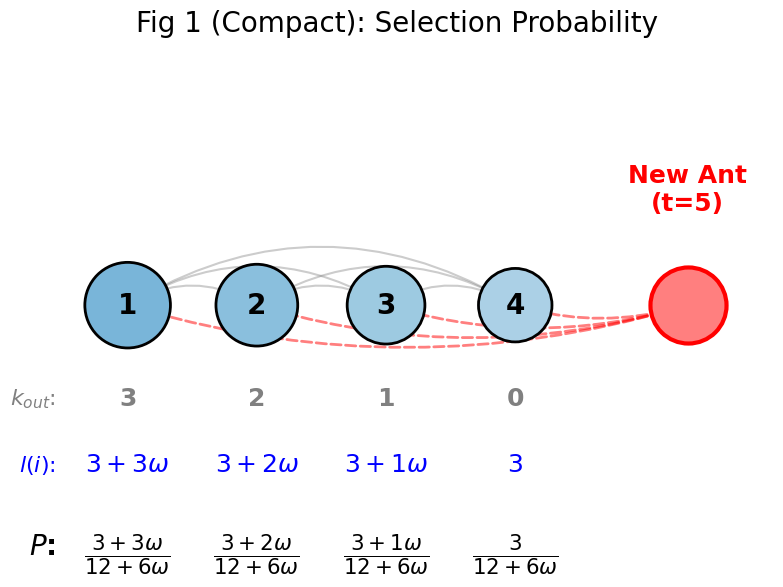


--- Regenerating Figure 2 (Fixed Hubs) ---


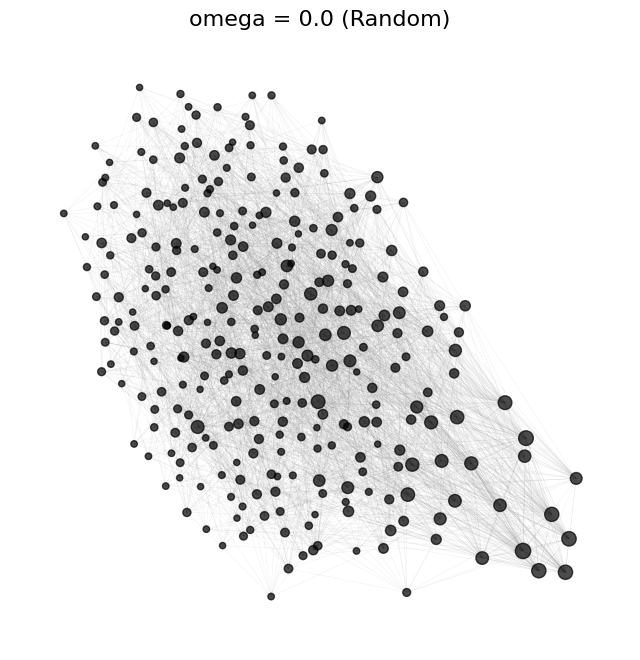

Generated fig4_2_3_fixed.png


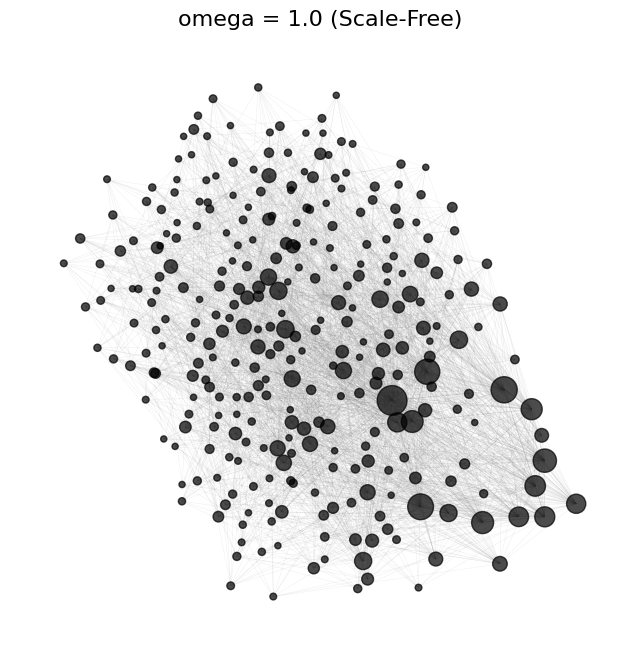

Generated fig4_2_4_fixed.png


In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# ==========================================
# 修正1: 図1 (コンパクト・高密度版)
# ==========================================
def draw_fig1_compact():
    r = 3
    t = 4
    
    # データを定義
    existing_nodes = [1, 2, 3, 4]
    new_node = 5
    k_outs = {1: 3, 2: 2, 3: 1, 4: 0}
    omega_val = 1.0
    denom_str = "12+6\\omega"

    # 数式と描画用スコアの準備
    formulas = {}
    l_vals = {}
    for n in existing_nodes:
        k = k_outs[n]
        if k > 0:
            numerator = f"3+{k}\\omega"
            l_vals[n] = 3 + k * omega_val
        else:
            numerator = "3"
            l_vals[n] = 3
        formulas[n] = f"$\\frac{{{numerator}}}{{{denom_str}}}$"

    total_l = sum(l_vals.values())
    probs_numeric = {n: l_vals[n] / total_l for n in existing_nodes}

    # --- 描画設定（ここが重要） ---
    # figsizeを正方形に近くする (横幅を狭く、高さを確保)
    # これにより width=7cm で配置したときに文字が相対的に大きく見える
    plt.figure(figsize=(8, 6)) 
    
    G = nx.DiGraph()
    G.add_nodes_from(existing_nodes)
    
    # ノード配置：間隔を詰め、少しカーブさせてスペースを有効活用
    # 一直線 (0,0) -> (3,0) ... だと横に長いので詰める
    pos = {1: (0, 0), 2: (1.8, 0), 3: (3.6, 0), 4: (5.4, 0), 5: (7.8, 0)}
    
    edges = [(2,1), (3,1), (3,2), (4,1), (4,2), (4,3)]

    # ノードサイズと色
    base_size = 1800
    node_sizes = [base_size + (probs_numeric[n] * 6000) for n in existing_nodes]
    node_colors = [plt.cm.Blues(0.2 + probs_numeric[n]*0.8) for n in existing_nodes]

    # 描画
    nx.draw_networkx_nodes(G, pos, nodelist=existing_nodes, 
                           node_size=node_sizes, node_color=node_colors, 
                           edgecolors='black', linewidths=2)
    
    # 新規ノード5
    nx.draw_networkx_nodes(G, pos, nodelist=[new_node], node_size=3000, 
                           node_color='#ff7f7f', edgecolors='red', linewidths=3)

    # ラベル (フォントサイズ特大)
    nx.draw_networkx_labels(G, pos, font_size=20, font_weight='bold')

    # エッジ (カーブを強めにしてコンパクトに見せる)
    nx.draw_networkx_edges(G, pos, edgelist=edges, 
                           connectionstyle="arc3,rad=0.3", 
                           edge_color='gray', alpha=0.4, arrowstyle='->', arrowsize=20, width=1.5)
    
    potential_edges = [(5, i) for i in existing_nodes]
    nx.draw_networkx_edges(G, pos, edgelist=potential_edges, 
                           style='dashed', edge_color='red', alpha=0.5, 
                           connectionstyle="arc3,rad=-0.15", arrowstyle='->', arrowsize=25, width=2.0)

    # --- テキスト情報 (配置調整) ---
    # アリ5
    plt.text(pos[5][0], 0.35, "New Ant\n(t=5)", ha='center', va='center', 
             fontsize=18, color='red', fontweight='bold')
    
    # 下部のパラメータ (y座標を上げて全体をコンパクトに)
    y_base = -0.3
    
    # ヘッダー (位置を調整)
    plt.text(-1.0, y_base, "$k_{out}$:", ha='right', fontsize=16, color='gray')
    plt.text(-1.0, y_base - 0.2, "$l(i)$:", ha='right', fontsize=16, color='blue')
    plt.text(-1.0, y_base - 0.45, "$P$:", ha='right', fontsize=20, fontweight='bold')

    for n in existing_nodes:
        x = pos[n][0]
        # k_out
        plt.text(x, y_base, f"{k_outs[n]}", ha='center', fontsize=18, color='gray', fontweight='bold')
        # l(i)
        l_text = f"$3+{k_outs[n]}\omega$" if k_outs[n]>0 else "$3$"
        plt.text(x, y_base - 0.2, l_text, ha='center', fontsize=18, color='blue')
        # 数式確率
        plt.text(x, y_base - 0.45, formulas[n], ha='center', va='center', fontsize=22)

    plt.title(f"Fig 1 (Compact): Selection Probability", fontsize=20)
    
    # 余白を極限まで削る
    plt.xlim(-1.5, 9.0)
    plt.ylim(-0.8, 0.8)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig("fig5_1_compact.png", dpi=300, bbox_inches='tight') # 保存時に余白カット
    plt.show()


# ==========================================
# 修正2: 図2 (omega=0, 1 のハブ修正版)
# ==========================================
def generate_aco_network(omega, r=10, t=300, seed=None):
    if seed is not None:
        np.random.seed(seed)
    
    G = nx.DiGraph()
    initial_ants = list(range(1, r + 2))
    G.add_nodes_from(initial_ants)
    
    # 初期完全グラフの接続を作成 (可視化レイアウトのため)
    # これがないと初期ノード同士が離れてしまうことがある
    for i in initial_ants:
        for j in initial_ants:
            if i != j:
                G.add_edge(i, j)

    k_out = {i: (r + 1) - i for i in initial_ants}
    
    for current_ant in range(r + 2, t + 1):
        G.add_node(current_ant)
        k_out[current_ant] = 0
        
        existing_ants = np.array(range(1, current_ant))
        k_vals = np.array([k_out[i] for i in existing_ants])
        l_vals = np.maximum(r + omega * k_vals, 0)
        
        if l_vals.sum() == 0:
            probs = np.ones(len(existing_ants)) / len(existing_ants)
        else:
            probs = l_vals / l_vals.sum()
            
        size_to_choose = min(r, len(existing_ants))
        chosen = np.random.choice(existing_ants, size=size_to_choose, replace=False, p=probs)
        
        for target in chosen:
            G.add_edge(current_ant, target)
            k_out[target] += 1
            
    return G, k_out

def plot_fig2_hubs_fixed():
    # omega = 0.0 (Random) と 1.0 (Scale-Free) のみを再生成
    omegas = [0.0, 1.0]
    r = 10
    t = 300
    seed_val = 42 # シード変更も検討できるが、Layoutパラメータで解決する
    
    for omega in omegas:
        G, k_out_dict = generate_aco_network(omega, r, t, seed=seed_val)
        degrees = np.array([k_out_dict[n] for n in G.nodes()])

        plt.figure(figsize=(8, 8))
        
        # --- レイアウト修正の肝 ---
        # k=None (デフォルト) にすることで、ノード密度に適した距離を自動計算させる
        # iterations=200 で十分に収束させ、不自然な飛び出しを防ぐ
        # 重みなしスプリングモデルを使用
        pos = nx.spring_layout(G, k=None, iterations=200, seed=42)
        
        # Scale-Freeの場合、中心にハブを集めたい
        if omega == 1.0:
            title = f"omega = {omega} (Scale-Free)"
            # ハブ強調サイズ (線形比例)
            node_sizes = [20 + 3.5 * d for d in degrees]
        else:
            title = f"omega = {omega} (Random)"
            node_sizes = [20 + 2 * d for d in degrees]

        # 描画
        nx.draw_networkx_nodes(G, pos, node_size=node_sizes, 
                               node_color='black', alpha=0.7)
        # エッジを薄く描画して「塊（ヘアボール）」感を出す
        nx.draw_networkx_edges(G, pos, width=0.3, alpha=0.15, arrows=False, edge_color='gray')
        
        plt.title(title, fontsize=16)
        plt.axis('off')
        
        # 保存
        filename = f"fig4_2_{'3' if omega==0 else '4'}_fixed.png"
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Generated {filename}")

if __name__ == "__main__":
    print("--- Regenerating Figure 1 (Compact) ---")
    draw_fig1_compact()
    print("\n--- Regenerating Figure 2 (Fixed Hubs) ---")
    plot_fig2_hubs_fixed()